# Plotting some rates

This is the first notebook, so just plotting around, and will condense into functions in single_neuron_utils.py under utils

In [1]:
import numpy as np 
import sys
from matplotlib import pyplot as plt
import matplotlib.patches as patches
import scipy
import os
import importlib
import pandas as pd

sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld 
import single_neuron_utils as sn 
import bhv_utils as bhv
from bootstrap_method import *



2025-05-15 15:24:00.934610: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-15 15:24:00.942647: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-15 15:24:00.951585: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-15 15:24:00.954200: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-15 15:24:00.961397: I tensorflow/core/platform/cpu_feature_guar

In [2]:
delay = 150
condn_phrase = 'delay'
condn_num = delay

# condn_key = f'{condn_phrase}{condn_num}'

In [3]:
# find folder names within model directory
all_models_dir = '/home/nuttidalab/Documents/renee/all_DMS_models/'

model_dirs = ld.get_immediate_subdirs(all_models_dir)
print(model_dirs)


['Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_231815', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_084645', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_212818', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_011809', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_163926', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_160648', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_225459', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_165543', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_221440', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_225727', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_175711', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_174328', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_204320', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_212723', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_234449', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_032739', 'Task_x

In [4]:
# choose a model to visualize for now
model_name = 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_152906'
model_dir = os.path.join(all_models_dir, model_name)

# find files for this delay of interest
data_files = ld.find_files_keywords(model_dir, [f'delay{delay}'])
print(data_files)

['/home/nuttidalab/Documents/renee/all_DMS_models/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_152906/acc_incorr_delay150.npy', '/home/nuttidalab/Documents/renee/all_DMS_models/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_152906/neuraldata_raw_delay150.mat', '/home/nuttidalab/Documents/renee/all_DMS_models/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_152906/acc_corr_stim2_delay150.npy', '/home/nuttidalab/Documents/renee/all_DMS_models/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_152906/bhvdata_raw_delay150.mat', '/home/nuttidalab/Documents/renee/all_DMS_models/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_152906/acc_corr_null_stim2_delay150.npy', '/home/nuttidalab/Documents/renee/all_DMS_models/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_152906/acc_corr_null_delay150.npy', '/home/nuttidalab/Documents/renee/all_DMS_models/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_152906/timingdata_raw_delay150.mat', '/home/nuttidalab/Documents/renee/al

In [5]:
# neural data
importlib.reload(ld)
_, _, rates_data = ld.load_neural_data(model_name, condn_phrase, condn_num,
                                                  load_LFP=False, load_spikes=False, load_rates=True)
# behavioral data
trial_labels, trial_perfs = ld.load_bhv_data(model_name, condn_phrase=condn_phrase, condn_num=condn_num)

# timing data
_, times_real, fs_dict = ld.load_timing_data(model_name, condn_phrase=condn_phrase, condn_num=condn_num)
times_ms, _,_ = ld.get_times_dict('ds', condn_phrase, condn_num, model_name)

In [6]:
rates_data.shape

(2055, 200, 1000)

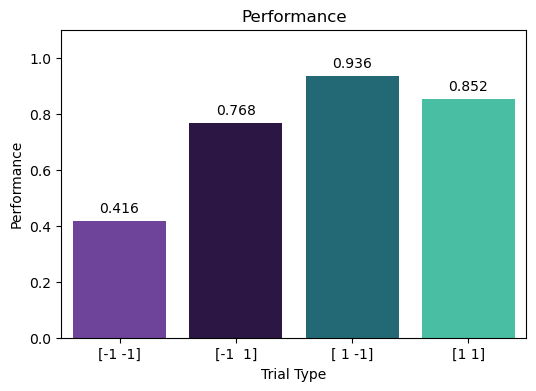

In [7]:
bhv.plot_trial_performance(model_name, condn_phrase, condn_num);

## Are there neurons consistently triggered at start of delay?

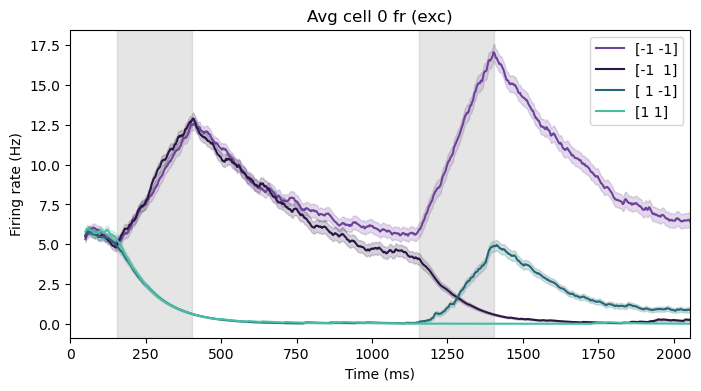

In [9]:
importlib.reload(sn)

sn.plot_neuron_rates(model_name, 0, condn_phrase, condn_num, rates_data = rates_data, cut_off=50)

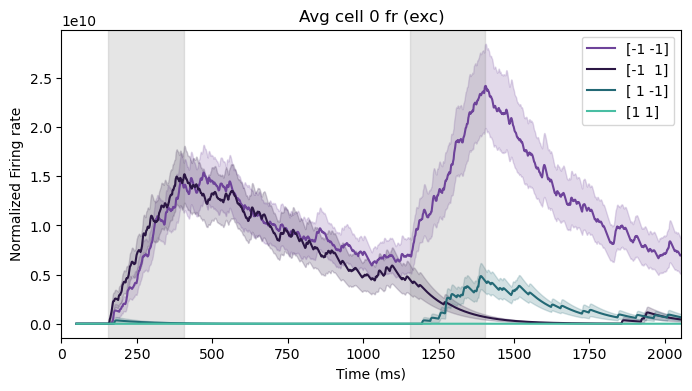

In [27]:
importlib.reload(sn)

sn.plot_neuron_rates(model_name, 0, condn_phrase, condn_num, rates_data = rates_data, cut_off=50, baseline=True)

### looking at mean across all trial types

In [75]:
half_window = 150
rates_mean = np.mean(rates_data, axis=2) # average across trial types, so (T x neurons)
stim1_end = np.mean(rates_mean[int(times_ms['stim1_off']-half_window):int(times_ms['stim1_off']),:], axis=0)
delay_start = np.mean(rates_mean[int(times_ms['stim1_off']):int(times_ms['stim1_off']+half_window),:], axis=0)

print(stim1_end.shape, delay_start.shape)

(200,) (200,)


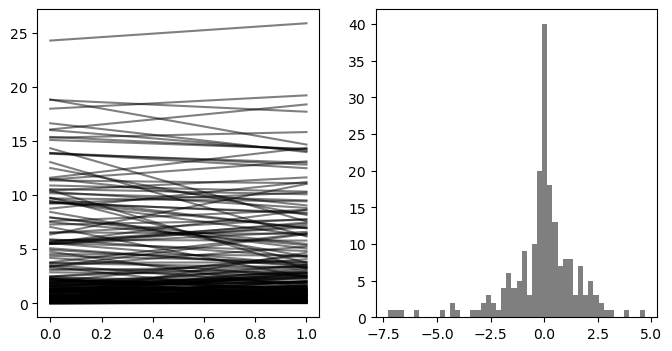

In [76]:
# plot lines
fig, ax = plt.subplots(1, 2, figsize=(8,4))

rate_change = np.concatenate((stim1_end[np.newaxis,:], delay_start[np.newaxis,:]), axis=0)

ax[0].plot(rate_change, color='k', alpha=0.5)
ax[1].hist(delay_start - stim1_end, bins=50, color='k', alpha=0.5)
plt.show()

### doing stats on all trials for all neurons

In [72]:
# rates_data is (T x neurons x trials)
half_window = 150
stim1_end = np.mean(rates_data[int(times_ms['stim1_off']-half_window):int(times_ms['stim1_off']),:,:], axis=0)
delay_start = np.mean(rates_data[int(times_ms['stim1_off']):int(times_ms['stim1_off']+half_window),:,:], axis=0)
print(stim1_end.shape, delay_start.shape)

(200, 1000) (200, 1000)


In [73]:
p_values_less = np.zeros(stim1_end.shape[0])
p_values_greater = np.zeros(stim1_end.shape[0])
for n_neuron in range(stim1_end.shape[0]):
    _,p = scipy.stats.mannwhitneyu(delay_start[n_neuron,:], stim1_end[n_neuron,:], alternative='less') # delay activity is less
    p_values_less[n_neuron] = p
    _,p = scipy.stats.mannwhitneyu(delay_start[n_neuron,:], stim1_end[n_neuron,:], alternative='greater') # delay activity is greater
    p_values_greater[n_neuron] = p
print(f'less: {np.sum(p_values_less<0.05)} neurons, greater: {np.sum(p_values_greater<0.05)} neurons')
print(f'less: {np.sum(p_values_less<0.01)} neurons, greater: {np.sum(p_values_greater<0.01)} neurons')
print(f'less: {np.sum(p_values_less<0.001)} neurons, greater: {np.sum(p_values_greater<0.001)} neurons')

less: 162 neurons, greater: 25 neurons
less: 161 neurons, greater: 21 neurons
less: 152 neurons, greater: 19 neurons


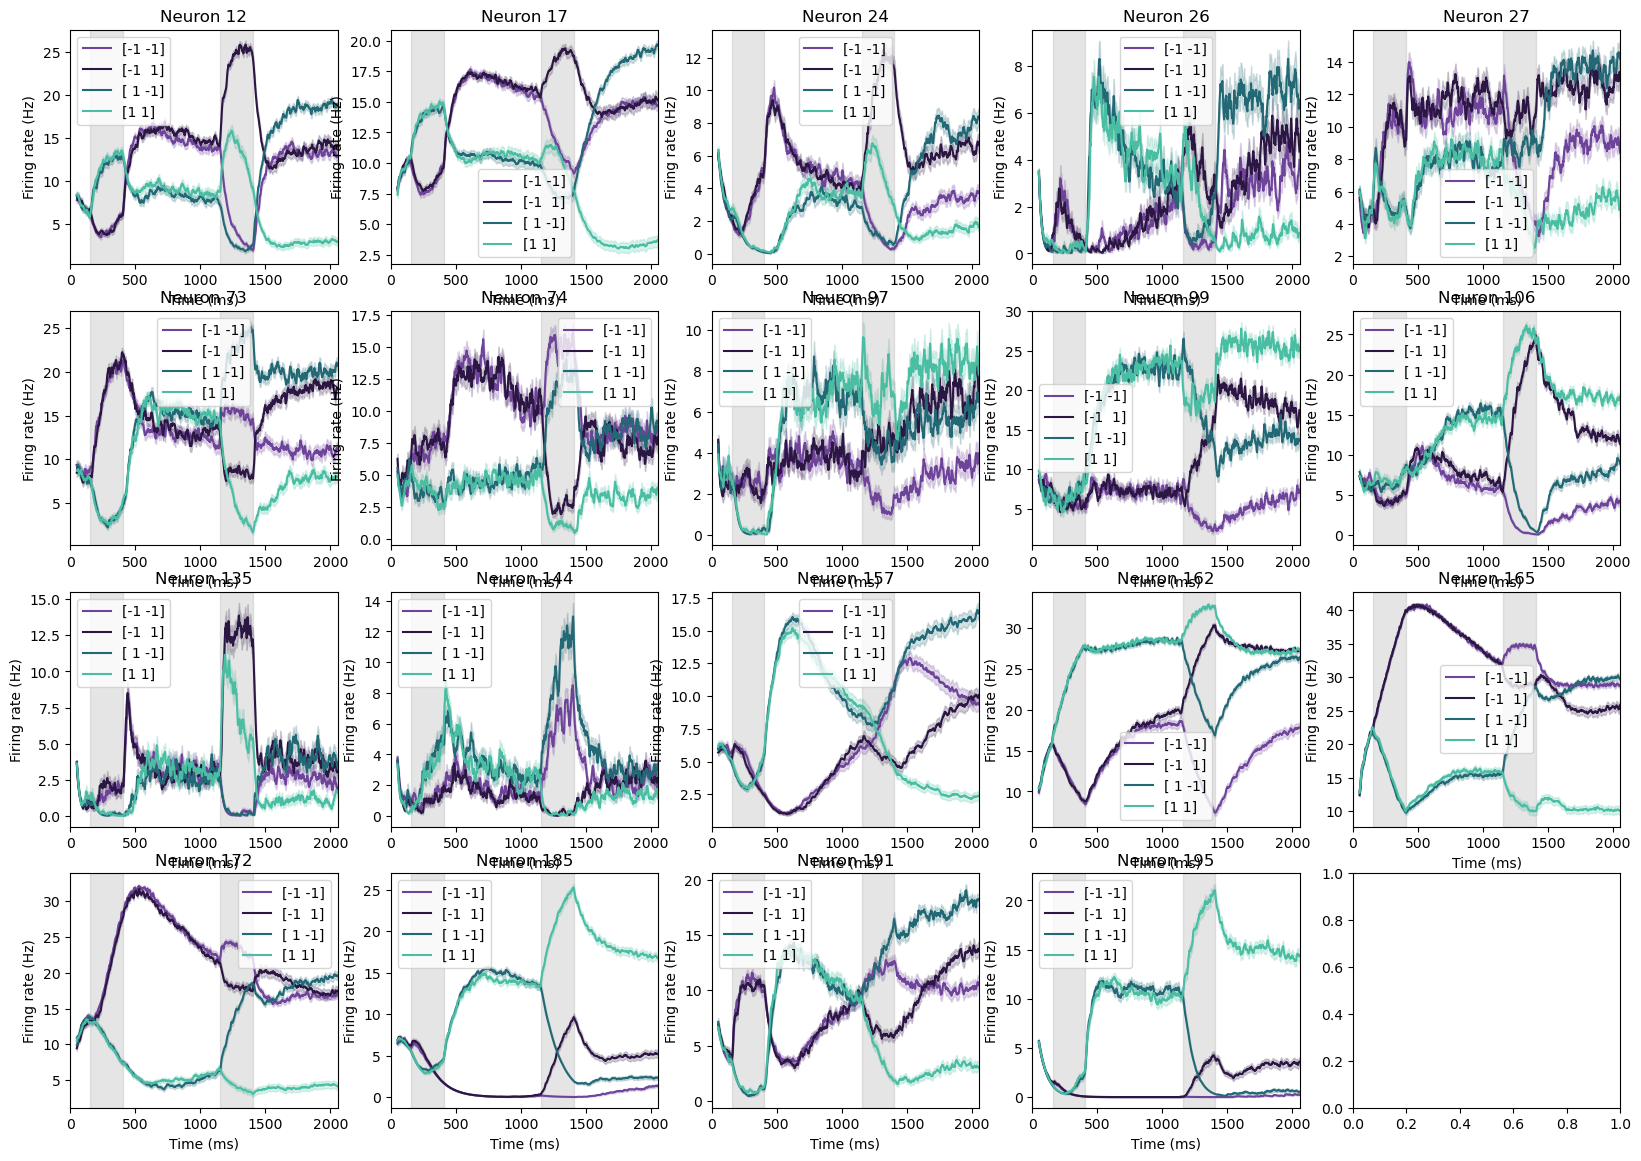

In [74]:
# let's take a look at the neurons that are significantly greater during delay

fig, axs = plt.subplots(4,5, figsize=(20,14))
axs = axs.flatten()
greater_neurons = np.where(p_values_greater<0.001)[0]
for n_neuron in range(len(greater_neurons)):
    sn.plot_neuron_rates(model_name, greater_neurons[n_neuron], condn_phrase, condn_num, rates_data = rates_data, cut_off=50, baseline=False, ax=axs[n_neuron])
    axs[n_neuron].set_title(f'Neuron {greater_neurons[n_neuron]}')

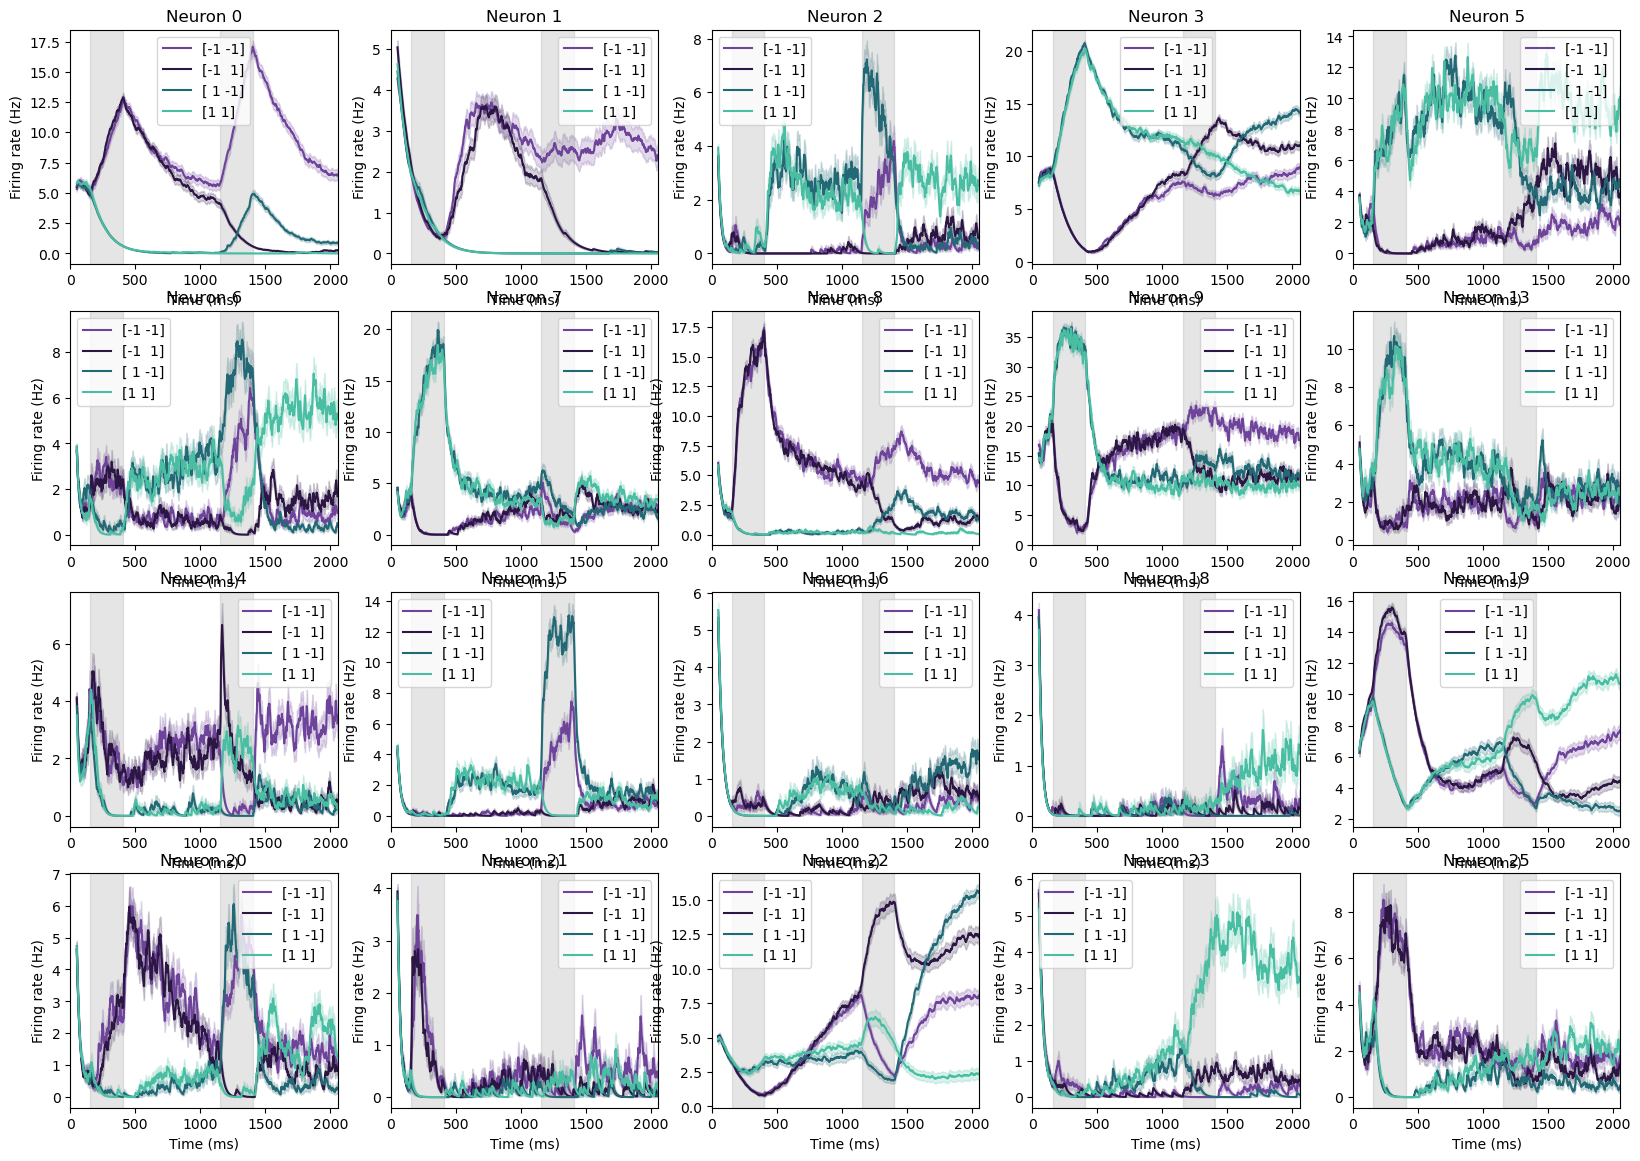

In [77]:
# let's take a look at the neurons that are significantly less during delay

fig, axs = plt.subplots(4,5, figsize=(20,14))
axs = axs.flatten()
less_neurons = np.where(p_values_less<0.001)[0]
for n_neuron in range(len(less_neurons)):
    sn.plot_neuron_rates(model_name, less_neurons[n_neuron], condn_phrase, condn_num, rates_data = rates_data, cut_off=50, baseline=False, ax=axs[n_neuron])
    axs[n_neuron].set_title(f'Neuron {less_neurons[n_neuron]}')
    if n_neuron == 19:
        break

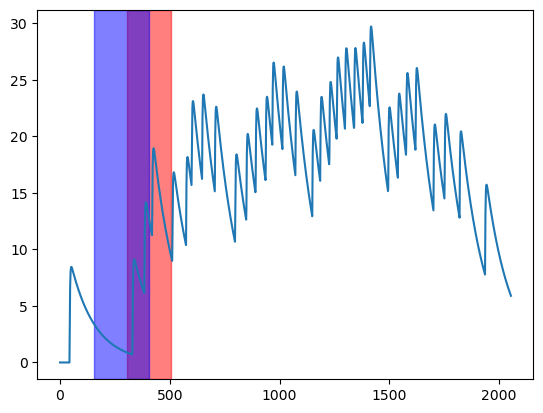

In [58]:
delay_start = times_ms['stim1_off']
delay_window = [delay_start - 100, delay_start + 100] # get a window around the delay
plt.plot(rates_data[:,0,0])
plt.axvspan(delay_window[0], delay_window[1], color='red', alpha=0.5);
plt.axvspan(times_ms['stim1_on'], times_ms['stim1_off'], color='blue', alpha=0.5);

## How are the tuning-based subpopulations contributing to the delay differently?

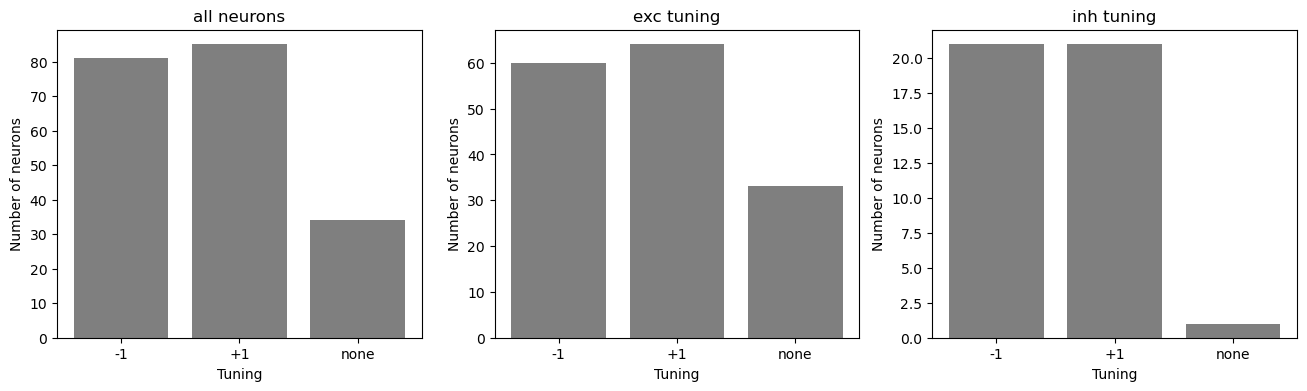

In [6]:
tuning = sn.calc_stim1_tuning(model_name, condn_phrase, condn_num)
exc_ind, inh_ind = ld.get_celltype_label(model_name)
fig, axs = plt.subplots(1, 3, figsize=(16, 4))
sn.plot_stim1_tuning(tuning, ax=axs[0], title='all neurons')
sn.plot_stim1_tuning(tuning, cell_idxs = exc_ind, ax=axs[1], title='exc tuning')
sn.plot_stim1_tuning(tuning, cell_idxs = inh_ind, ax=axs[2], title='inh tuning')

### what are untuned neurons doing?

Number of untuned neurons: 34


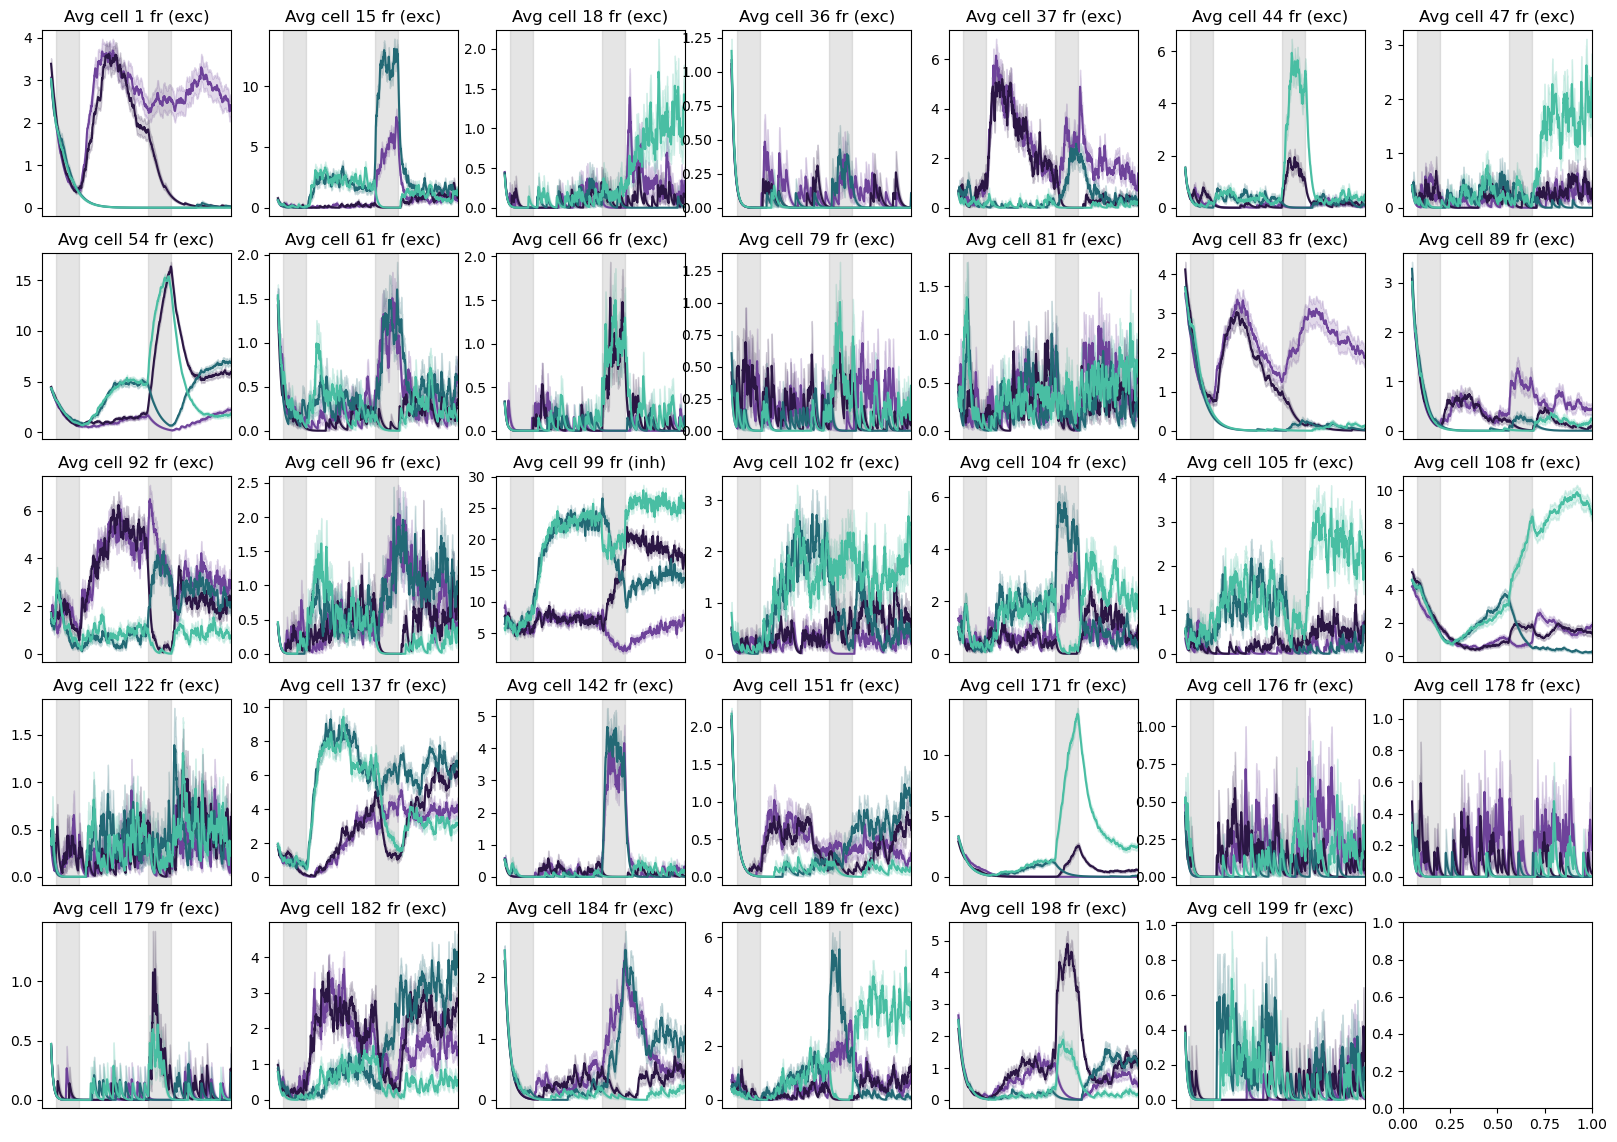

In [7]:
untuned_idxs = np.where(np.isnan(tuning))[0]
print(f'Number of untuned neurons: {len(untuned_idxs)}')

# plot the tuning curves for the untuned neurons
fig, axs = plt.subplots(5, 7, figsize=(20, 14))
axs = axs.flatten()
for n_neuron in range(len(untuned_idxs)):
    sn.plot_neuron_rates(model_name, untuned_idxs[n_neuron], condn_phrase, condn_num, rates_data = rates_data, cut_off=100, baseline=False, ax=axs[n_neuron])
    # turn off x axis labels
    axs[n_neuron].set_xticks([])
    axs[n_neuron].set_xlabel('')
    axs[n_neuron].set_ylabel('')
    # turn off legend
    axs[n_neuron].legend().set_visible(False)
    
    if n_neuron == 34:
        break

In [8]:
# check the connectivity of the untuned neurons
connectivity_df = ld.get_connectivity_df(model_name)
# get the connectivity of the untuned neurons
untuned_connectivity = connectivity_df[connectivity_df['postsyn_id'].isin(untuned_idxs)]
# sort the connectivity by the postsynaptic neuron
untuned_connectivity = untuned_connectivity.sort_values(by='postsyn_id')
untuned_connectivity

,presyn_id,postsyn_id,weight,presyn_type,postsyn_type
1230,162,1,-0.060857,inh,exc
63,8,1,-0.024028,inh,exc
1120,144,1,-0.033868,inh,exc
1462,185,1,-0.054552,inh,exc
704,78,1,-0.038593,inh,exc
...,...,...,...,...,...
62,7,199,-0.020982,inh,exc
314,26,199,-0.015263,inh,exc
1155,144,199,-0.025055,inh,exc
224,12,199,-0.029704,inh,exc


Average number of presyn neurons per untuned neuron: 10.117647058823529


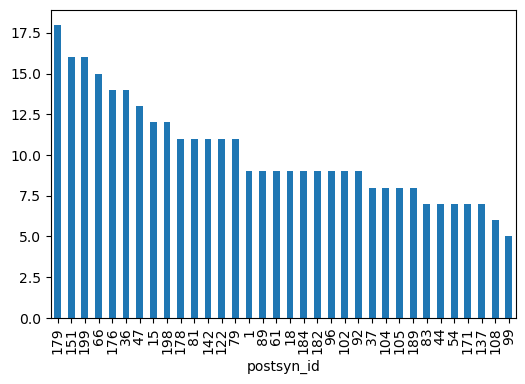

In [9]:
# plot the number of connections per untuned neuron
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
untuned_connectivity['postsyn_id'].value_counts().plot(kind='bar', ax=ax)
# average number of presyn neurons per untuned neuron
avg_num_presyn = np.mean(untuned_connectivity['postsyn_id'].value_counts())
print(f'Average number of presyn neurons per untuned neuron: {avg_num_presyn}')

Neuron 66 has 1 exc connections
Neuron 81 has 1 exc connections
Neuron 99 has 1 exc connections
Neuron 176 has 1 exc connections
Neuron 178 has 1 exc connections
Neuron 179 has 2 exc connections


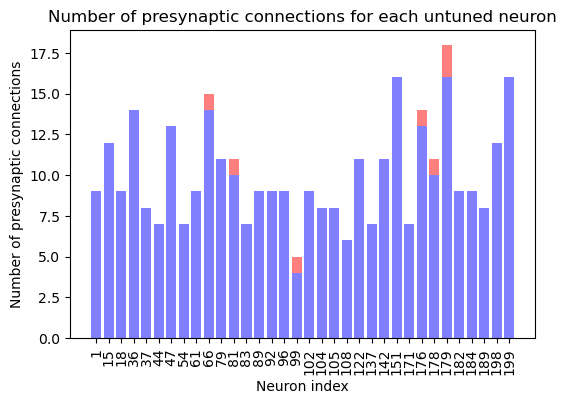

In [24]:
# plot number of presynaptic connections for each untuned, with exc and inh colored differently

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
for n_neuron, neuron_idx in enumerate(untuned_idxs):
    # get the number of presynaptic connections for this neuron
    presyn_df = untuned_connectivity[untuned_connectivity['postsyn_id'] == neuron_idx]
    # get the number of presynaptic connections for this neuron
    n_inh = np.sum(presyn_df['presyn_type'] == 'inh')
    n_exc = np.sum(presyn_df['presyn_type'] == 'exc')
    num_presyn = len(untuned_connectivity[untuned_connectivity['postsyn_id'] == neuron_idx])
    if n_inh + n_exc != num_presyn:
        print(f'Neuron {neuron_idx} has {num_presyn} presynaptic connections, but {n_inh} inh and {n_exc} exc')
    
    # plot the number of presynaptic connections for this neuron
    if n_inh > 0:
        ax.bar(n_neuron, n_inh, color='blue', alpha=0.5)
    if n_exc > 0:
        print(f'Neuron {neuron_idx} has {n_exc} exc connections')
        ax.bar(n_neuron, n_exc, bottom=n_inh, color='red', alpha=0.5)

# set the x ticks to be the neuron indices
ax.set_xticks(np.arange(len(untuned_idxs)))
ax.set_xticklabels(untuned_idxs, rotation=90)
# set the x label
ax.set_xlabel('Neuron index')
# set the y label
ax.set_ylabel('Number of presynaptic connections')
# set the title
ax.set_title('Number of presynaptic connections for each untuned neuron')
plt.show()

Average number of presynaptic connections per neuron: 8.03
Average number of presynaptic connections per exc neuron: 8.445859872611464


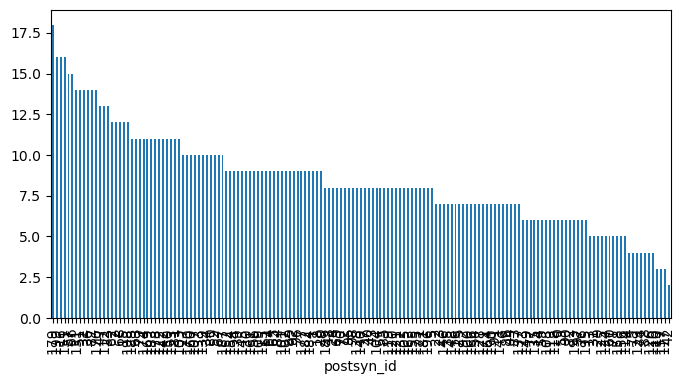

In [31]:
# average number presyn connections per neuron
avg_presyn = np.mean(connectivity_df['postsyn_id'].value_counts())
print(f'Average number of presynaptic connections per neuron: {avg_presyn}')

# average number presyn connections per exc neuron
exc_connectivity = connectivity_df[connectivity_df['postsyn_id'].isin(exc_ind)]
exc_connectivity = exc_connectivity.sort_values(by='postsyn_id')
# plot the number of connections per exc neuron
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
exc_connectivity['postsyn_id'].value_counts().plot(kind='bar', ax=ax)
# average number presyn connections per unique neuron
avg_presyn = np.mean(exc_connectivity['postsyn_id'].value_counts())
print(f'Average number of presynaptic connections per exc neuron: {avg_presyn}')

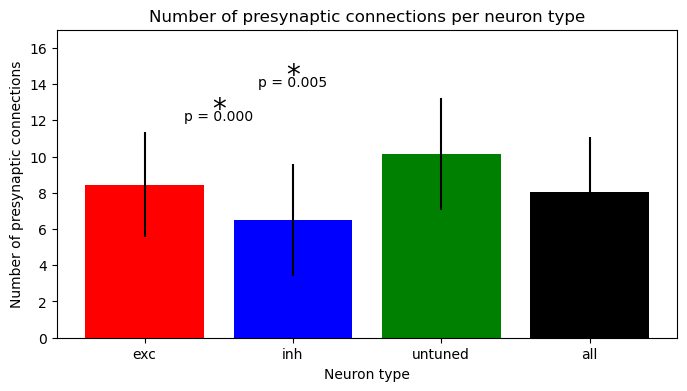

In [43]:
# bar plot for avg # presyn connections per category, with error bars and stats

# get the number of presynaptic connections per neuron
def get_num_presyn(connectivity_df, neuron_idxs):
    # get the connectivity of the neurons of interest
    connectivity = connectivity_df[connectivity_df['postsyn_id'].isin(neuron_idxs)]
    # sort the connectivity by the postsynaptic neuron
    connectivity = connectivity.sort_values(by='postsyn_id')
    # get the number of presynaptic connections per neuron
    num_presyn = connectivity['postsyn_id'].value_counts()

    # if some neuron idxs weren't included, add them as rows of zeros
    for neuron_idx in neuron_idxs:
        if neuron_idx not in num_presyn.index:
            num_presyn[neuron_idx] = 0
    # sort the index
    num_presyn = num_presyn.sort_index()

    return num_presyn
# get the number of presynaptic connections per neuron for each category
exc_num_presyn = get_num_presyn(connectivity_df, exc_ind)
exc_ind_tuned = np.setdiff1d(exc_ind, untuned_idxs) # exclude the exc neurons that are also untuned
exc_tuned_num_presyn = get_num_presyn(connectivity_df, exc_ind_tuned) # exclude the exc neurons that are also untuned
inh_num_presyn = get_num_presyn(connectivity_df, inh_ind)
inh_ind_tuned = np.setdiff1d(inh_ind, untuned_idxs) # exclude the inh neurons that are also untuned
inh_tuned_num_presyn = get_num_presyn(connectivity_df, inh_ind_tuned) # exclude the inh neurons that are also untuned
# get the number of presynaptic connections per neuron for the untuned neurons
untuned_num_presyn = get_num_presyn(connectivity_df, untuned_idxs)
# get the number of presynaptic connections per neuron for all neurons
all_num_presyn = get_num_presyn(connectivity_df, np.arange(0, rates_data.shape[1]))


# plot barplot
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
# get the mean and std of the number of presynaptic connections per neuron
exc_mean = np.mean(exc_num_presyn)
exc_std = np.std(exc_num_presyn)
inh_mean = np.mean(inh_num_presyn)
inh_std = np.std(inh_num_presyn)
untuned_mean = np.mean(untuned_num_presyn)
untuned_std = np.std(untuned_num_presyn)
all_mean = np.mean(all_num_presyn)
all_std = np.std(all_num_presyn)

# plot the barplot
ax.bar(['exc', 'inh', 'untuned', 'all'], [exc_mean, inh_mean, untuned_mean, all_mean], yerr=[exc_std, inh_std, untuned_std, all_std], color=['r', 'b', 'g', 'k'])
ax.set_ylabel('Number of presynaptic connections')
ax.set_xlabel('Neuron type')
ax.set_title('Number of presynaptic connections per neuron type')
# add stats
exc_inh_p = scipy.stats.mannwhitneyu(exc_num_presyn, inh_num_presyn, alternative='two-sided')[1]
exc_untuned_p = scipy.stats.mannwhitneyu(exc_num_presyn, untuned_num_presyn, alternative='two-sided')[1]
# inh_untuned_p = scipy.stats.mannwhitneyu(inh_num_presyn, untuned_num_presyn, alternative='two-sided')[1]
ax.text(0.5, exc_mean+exc_std+0.5, f'p = {exc_inh_p:.3f}', ha='center', va='bottom')
ax.text(1, untuned_mean+untuned_std+0.5, f'p = {exc_untuned_p:.3f}', ha='center', va='bottom')
# ax.text(2, untuned_mean+untuned_std+0.5, f'p = {inh_untuned_p:.3f}', ha='center', va='bottom')
# add significance stars
if exc_inh_p < 0.05:
    ax.text(0.5, exc_mean+exc_std+0.5, '*', ha='center', va='bottom', fontsize=20)
if exc_untuned_p < 0.05:
    ax.text(1, untuned_mean+untuned_std+0.5, '*', ha='center', va='bottom', fontsize=20)

ax.set_ylim(0, 17)

plt.show()

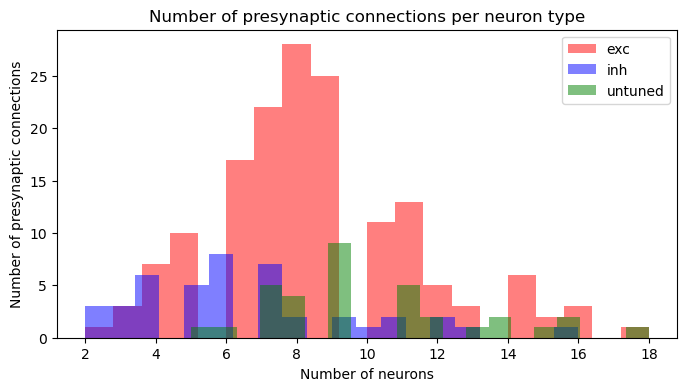

In [ ]:
# plot as histogram
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.hist(exc_num_presyn, bins=20, alpha=0.5, color='r', label='exc')
ax.hist(inh_num_presyn, bins=20, alpha=0.5, color='b', label='inh')
ax.hist(untuned_num_presyn, bins=20, alpha=0.5, color='g', label='untuned')

ax.legend()
ax.set_ylabel('Number of presynaptic connections')
ax.set_xlabel('Number of neurons')
ax.set_title('Number of presynaptic connections per neuron type')
plt.show()

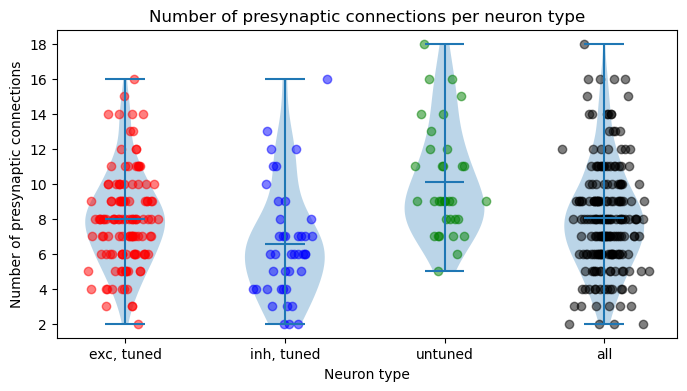

exc vs inh p = 0.00005
exc tuned vs inh tuned p = 0.00160
exc tuned vs untuned p = 0.00043


In [ ]:
# plot as violinplot

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.violinplot([exc_tuned_num_presyn, inh_tuned_num_presyn, untuned_num_presyn, all_num_presyn], showmeans=True)
# plot scatter points
ax.scatter(np.random.normal(1, 0.1, size=len(exc_tuned_num_presyn)), exc_tuned_num_presyn, color='r', alpha=0.5)
ax.scatter(np.random.normal(2, 0.1, size=len(inh_tuned_num_presyn)), inh_tuned_num_presyn, color='b', alpha=0.5)
ax.scatter(np.random.normal(3, 0.1, size=len(untuned_num_presyn)), untuned_num_presyn, color='g', alpha=0.5)
ax.scatter(np.random.normal(4, 0.1, size=len(all_num_presyn)), all_num_presyn, color='k', alpha=0.5)
ax.set_ylabel('Number of presynaptic connections')
ax.set_xlabel('Neuron type')
ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels(['exc, tuned', 'inh, tuned', 'untuned', 'all'])
ax.set_title('Number of presynaptic connections per neuron type')
plt.show()


# stats on this
exc_inh_p = scipy.stats.mannwhitneyu(exc_num_presyn, inh_num_presyn, alternative='two-sided')[1]
exc_inh_tuned_p = scipy.stats.mannwhitneyu(exc_tuned_num_presyn, inh_tuned_num_presyn, alternative='two-sided')[1]
exc_untuned_p = scipy.stats.mannwhitneyu(exc_tuned_num_presyn, untuned_num_presyn, alternative='two-sided')[1]

print(f'exc vs inh p = {exc_inh_p:.5f}')
print(f'exc tuned vs inh tuned p = {exc_inh_tuned_p:.5f}')
print(f'exc tuned vs untuned p = {exc_untuned_p:.5f}')


#### comparing correct and incorrect

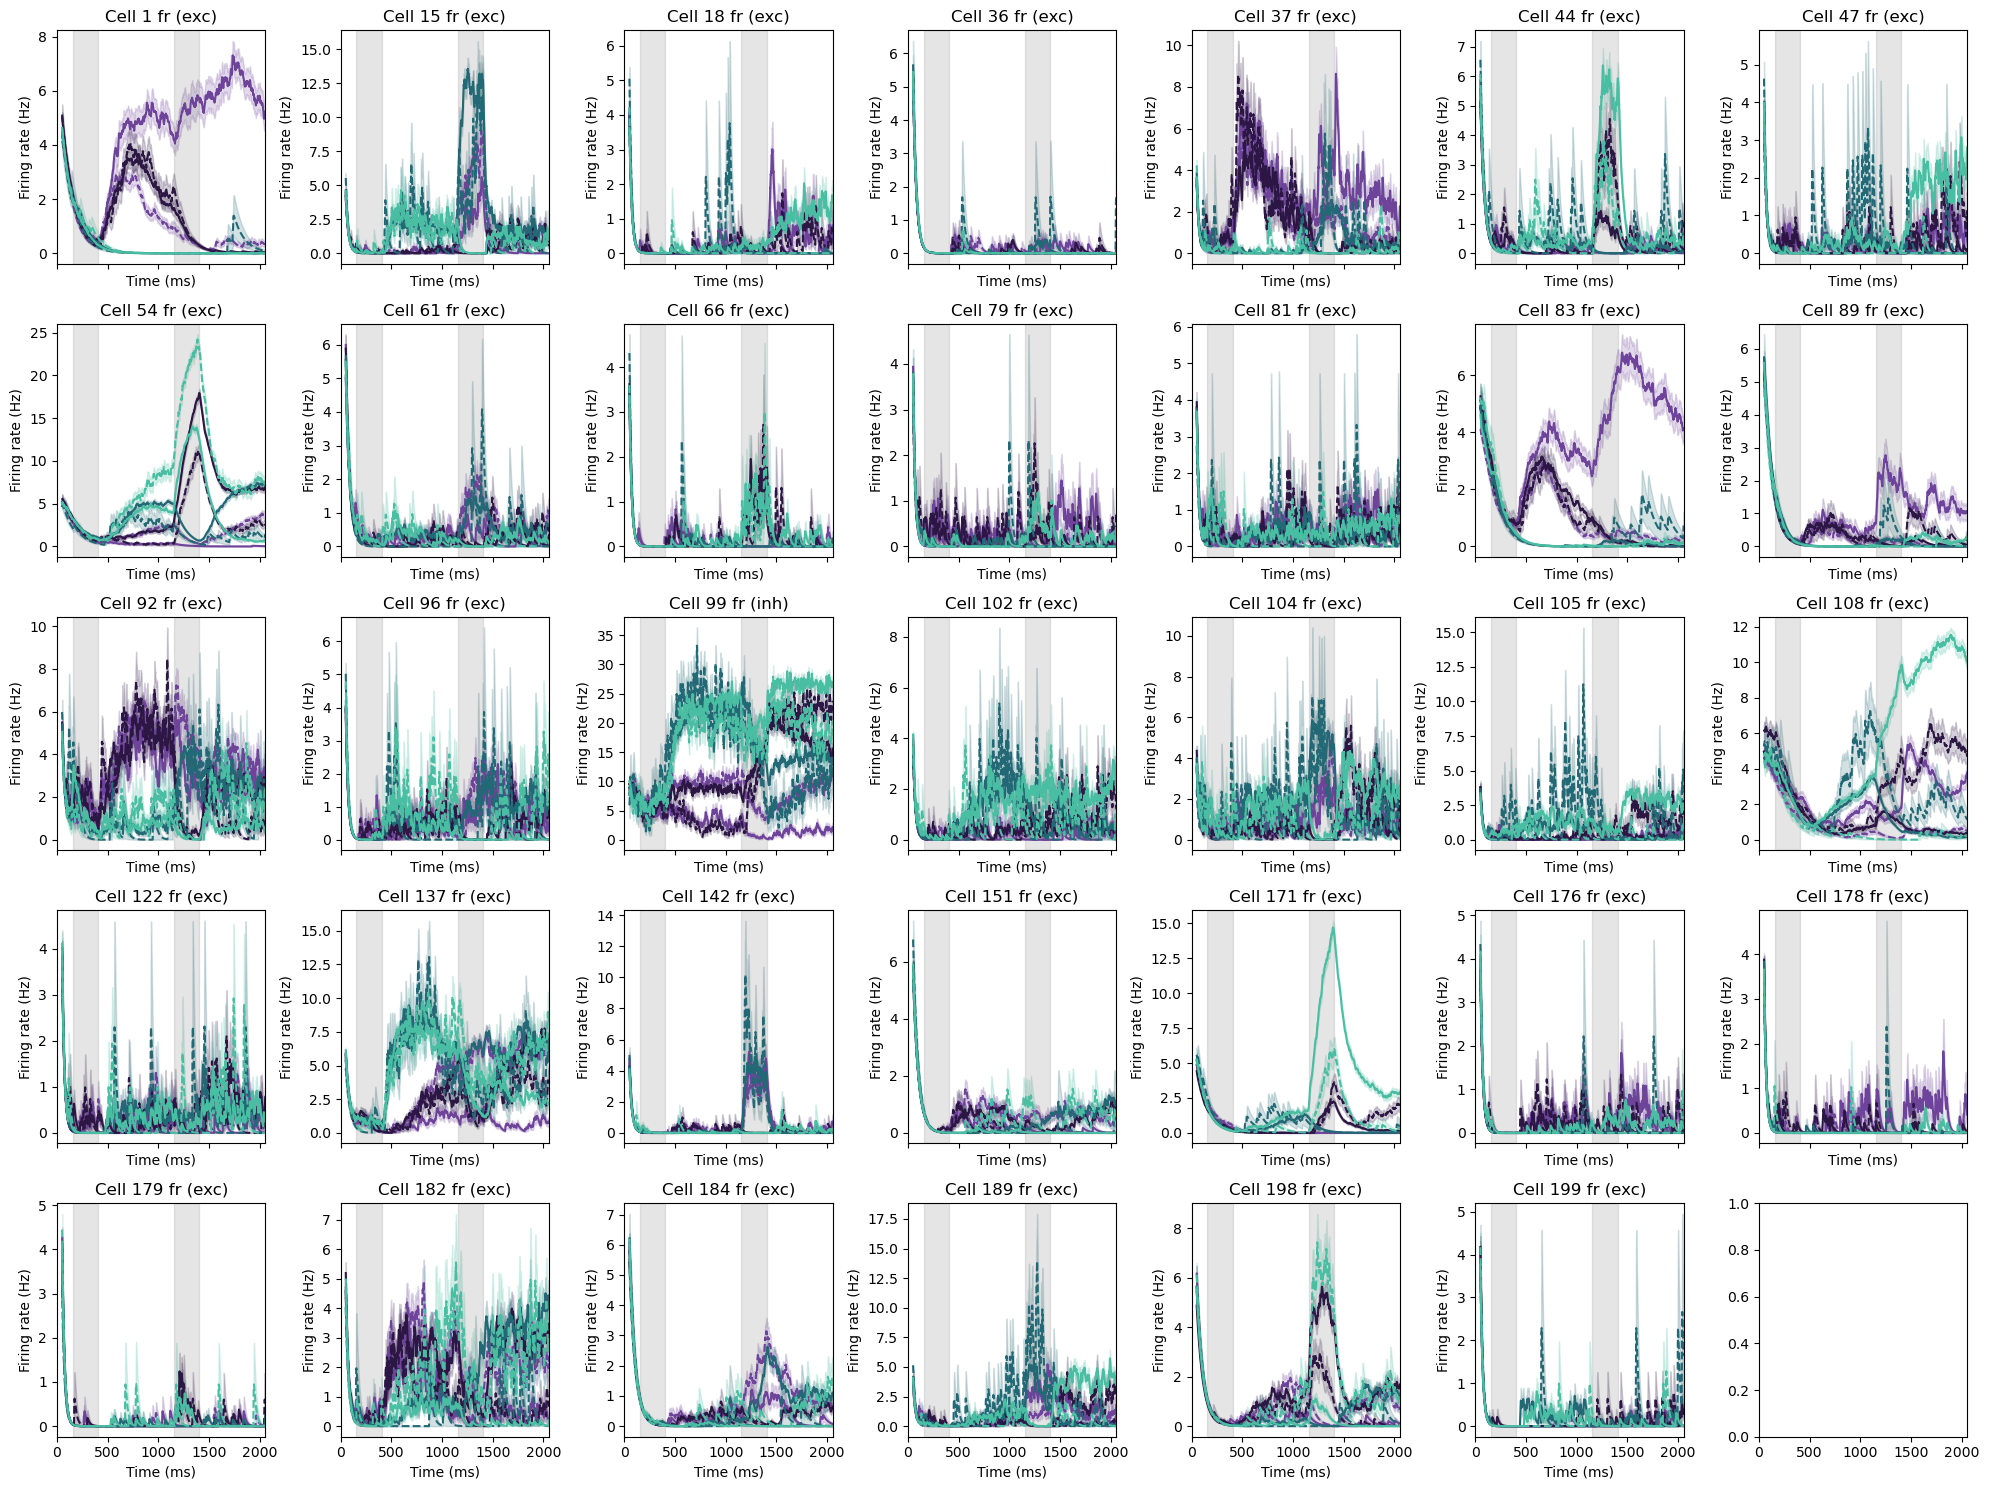

In [49]:
importlib.reload(sn)
cut_off = 50

fig, axs = plt.subplots(5, 7, figsize=(20, 15), sharex=True)
axs = axs.flatten()
for i, n_cell in enumerate(untuned_idxs):
    sn.plot_neuron_rates_by_acc(model_name, n_cell, condn_phrase, condn_num, rates_data = rates_data, cut_off=cut_off, ax=axs[i])

plt.tight_layout()
plt.show()

In [50]:
periods = {
    'stim1': [int(times_ms['stim1_on']), int(times_ms['stim1_off'])],
    'delay_half1': [int(times_ms['stim1_off']), int(times_ms['stim1_off'] + times_ms['delay']/2)],
    'delay_half2': [int(times_ms['stim1_off'] + times_ms['delay']/2), int(times_ms['stim2_on'])],
    'stim2': [int(times_ms['stim2_on']), int(times_ms['stim2_off'])],
}
periods

{'stim1': [155, 405],
 'delay_half1': [405, 780],
 'delay_half2': [780, 1155],
 'stim2': [1155, 1405]}

In [51]:
rates_data.shape

(2055, 200, 1000)

In [107]:
def plot_violin_neuron_rates_timeavg_by_acc(model_name, cell_idx, condn_phrase, condn_num, 
                                            rates_data = None, periods = None, plot=False,
                                            ax=None, title=None):
    """
    Plot the firing rates of a neuron across trials.
    
    Parameters:
    - model_name: Name of the model.
    - cell_id: ID of the neuron.
    - condn_phrase: Condition phrase for loading data.
    - condn_num: Condition number for loading data.
    """
    # Load the firing rates
    if rates_data is None:
        _, _, rates_data = ld.load_neural_data(model_name, condn_phrase, condn_num,
                                                    load_LFP=False, load_spikes=False, load_rates=True)

    exc_ind, inh_ind = ld.get_celltype_label(model_name)
    cell_type = 'exc' if cell_idx in exc_ind else 'inh'

    # behavioral data
    trial_labels, trial_perfs = ld.load_bhv_data(model_name, condn_phrase, condn_num)

    # get timing info
    times_ms, times_real, fs_dict = ld.get_times_dict('ds', condn_phrase, condn_num) #ds is fs=1000, ms

    if periods is None:
        periods = {
            'stim1': [int(times_ms['stim1_on']), int(times_ms['stim1_off'])],
            'delay_half1': [int(times_ms['stim1_off']), int(times_ms['stim1_off'] + times_ms['delay']/2)],
            'delay_half2': [int(times_ms['stim1_off'] + times_ms['delay']/2), int(times_ms['stim2_on'])],
            'stim2': [int(times_ms['stim2_on']), int(times_ms['stim2_off'])],
            }

    # plot firing rate for each trial type
    trial_types, trial_idxs = np.unique(trial_labels, axis=0, return_inverse=True)
    
    period_means = []
    for period in periods.keys():
        period_start = periods[period][0]
        period_end = periods[period][1]
        rates_period = np.mean(rates_data[period_start:period_end, cell_idx, :], axis=0) # n_trials

        for i, trial_type in enumerate(trial_types):
            trials_idx = (trial_idxs == i)

            # save all values
            period_means.append({
                'period': period,
                'trial_type': trial_type,
                'correct_rates': rates_period[(trials_idx) & (trial_perfs == 1)],
                'incorrect_rates': rates_period[(trials_idx) & (trial_perfs == 0)],
            })
    period_means = pd.DataFrame(period_means)

    # start plotting
    if plot:
        _, colors = sn.get_trialtype_colors()
        fig, axs = plt.subplots(1,len(periods.keys()), figsize=(20, 4), sharey=True)
        # fig, axs = plt.subplots(1,len(periods.keys()), figsize=(20, 4), sharey=False)
        for i, period in enumerate(periods.keys()):
            period_data = period_means[period_means['period'] == period]
            ax_labels = []
            for j, (_, trial_data) in enumerate(period_data.iterrows()):
                bp = axs[i].boxplot([trial_data['correct_rates'], trial_data['incorrect_rates']],
                            positions=[j-.2, j+0.2], widths=0.3, patch_artist=True)
                # color the boxes
                for k, box in enumerate(bp['boxes']):
                    box.set_facecolor(colors[j])  # Set the face color of the box
                    box.set_edgecolor('black')  # Optionally set edge color
                    box.set_alpha(0.5)  # Set transparency (optional)
                ax_labels.append(f'{trial_data["trial_type"]})')
                # add stats between correct and incorrect
                _, p = scipy.stats.mannwhitneyu(trial_data['correct_rates'], trial_data['incorrect_rates'], alternative='two-sided')
                # add significance stars
                if p < 0.05:
                    axs[i].text(j, np.max(np.concatenate((trial_data['correct_rates'], trial_data['incorrect_rates']))) + 0.5, '*', ha='center', va='bottom', fontsize=20)
                    axs[i].text(j, np.max(np.concatenate((trial_data['correct_rates'], trial_data['incorrect_rates']))) + 0.5, f'p = {p:.3f}', ha='center', va='bottom')
            axs[i].set_xticks(np.arange(len(ax_labels)))
            axs[i].set_xticklabels(ax_labels)
            axs[i].set_title(period)
        axs[0].set_ylabel('Firing rate (Hz)');

        if title is not None:
            fig.suptitle(f'{title}')
        else:
            fig.suptitle(f'Cell {cell_idx} fr ({cell_type})')
        
    return period_means

In [101]:
# get untuned neurons with highest number of presynaptic connections
untuned_connectivity = connectivity_df[connectivity_df['postsyn_id'].isin(untuned_idxs)]
untuned_connectivity = untuned_connectivity.sort_values(by='postsyn_id')
top_untuned_neurons = untuned_connectivity['postsyn_id'].value_counts().head(5).index
print(f'Top 5 untuned neurons with the most presynaptic connections: {top_untuned_neurons}')

Top 5 untuned neurons with the most presynaptic connections: Index([179, 151, 199, 66, 176], dtype='int64', name='postsyn_id')


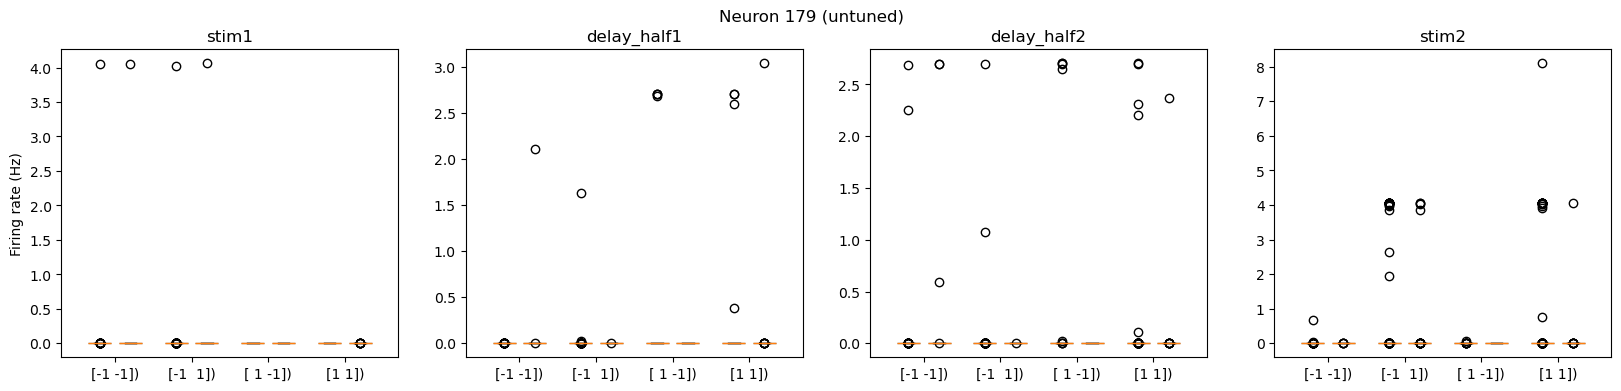

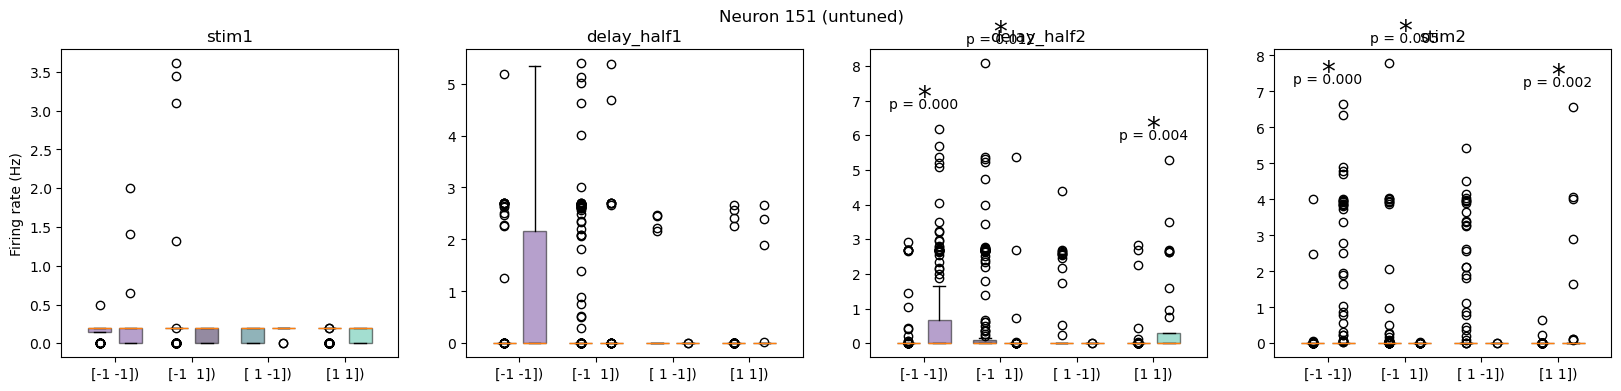

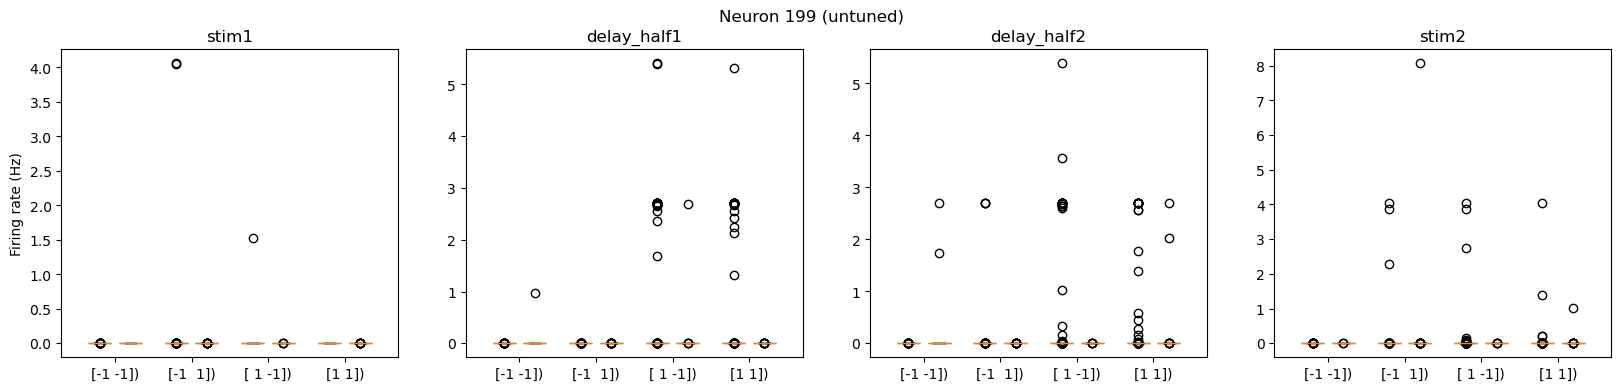

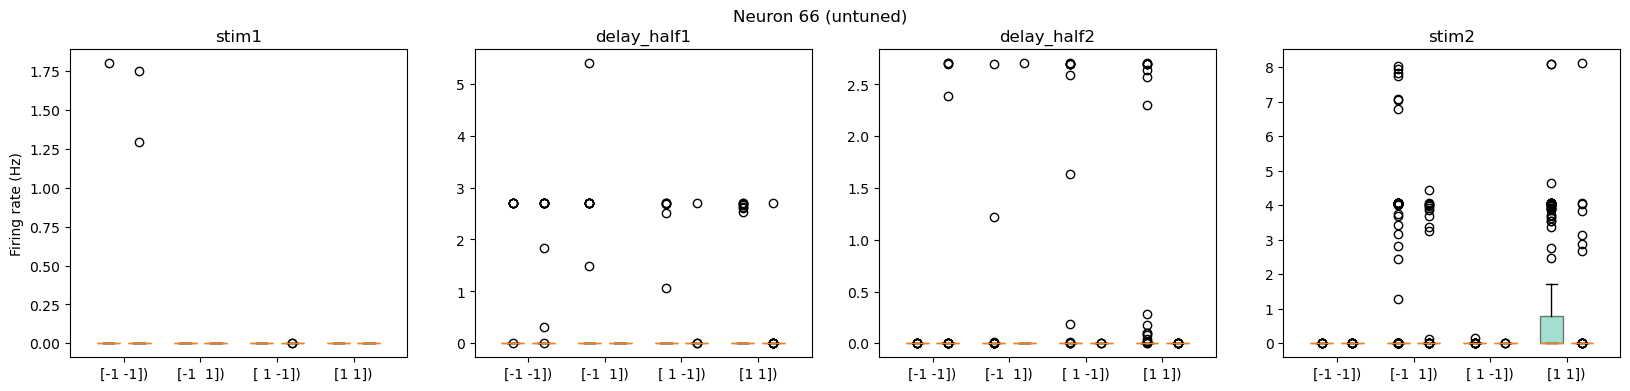

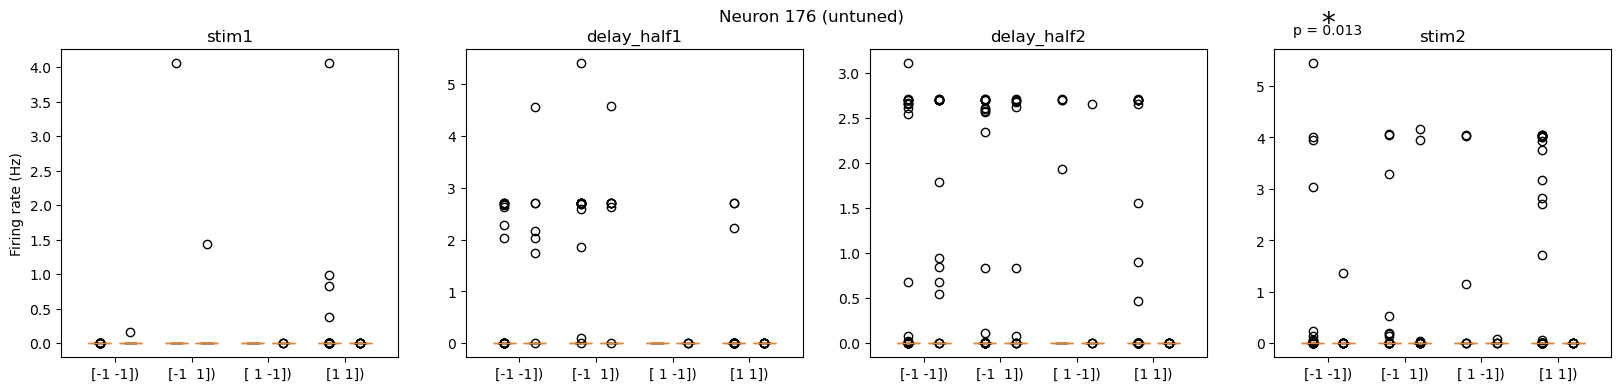

In [106]:
for neuron_idx in top_untuned_neurons:
    # print(f'Neuron {neuron_idx}')
    plot_violin_neuron_rates_timeavg_by_acc(model_name, neuron_idx, condn_phrase, condn_num, 
                                            rates_data = rates_data, periods = periods, plot=True,
                                            title=f'Neuron {neuron_idx} (untuned)')

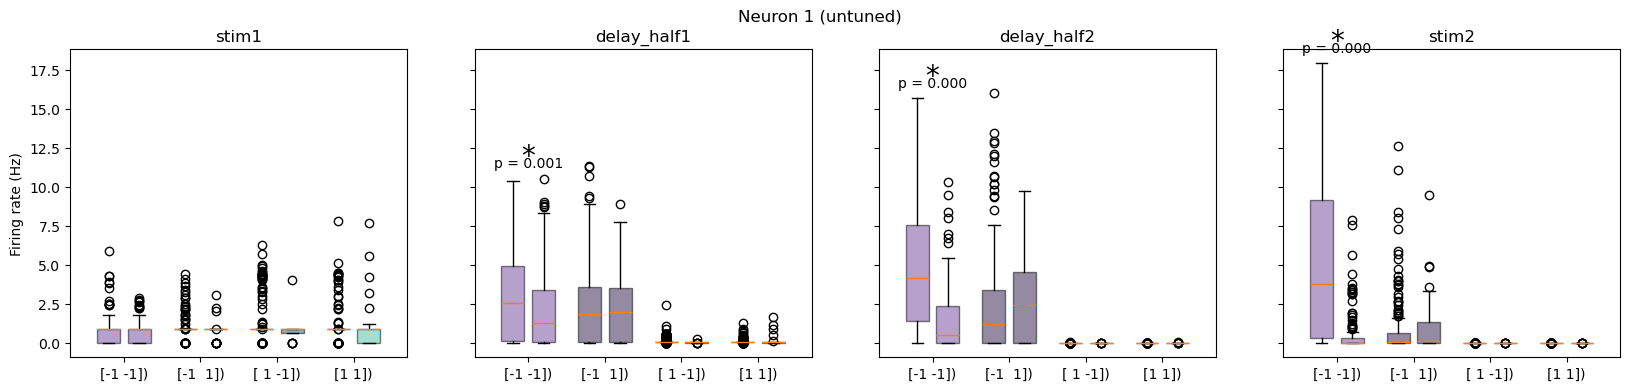

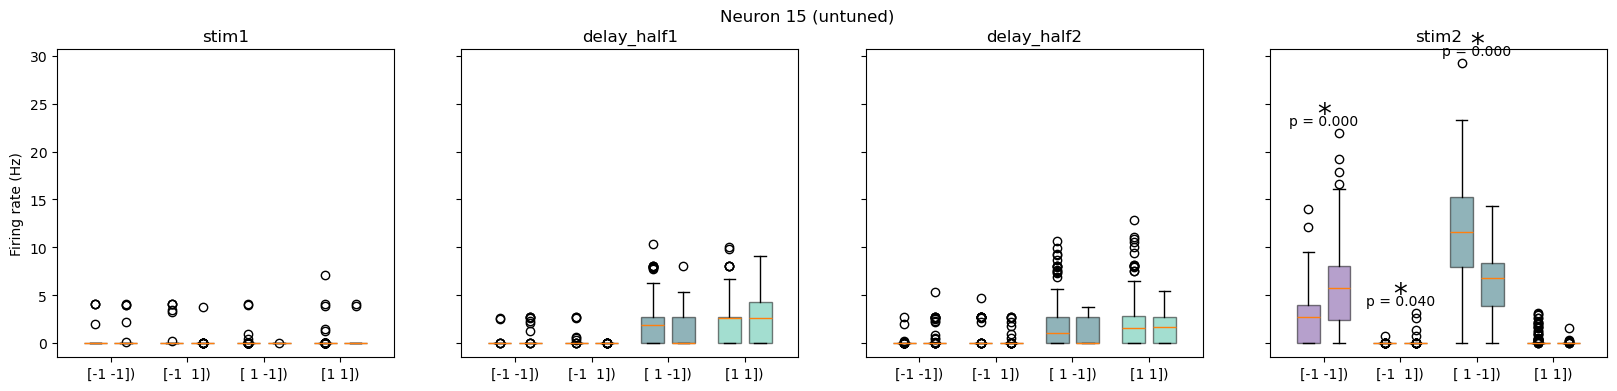

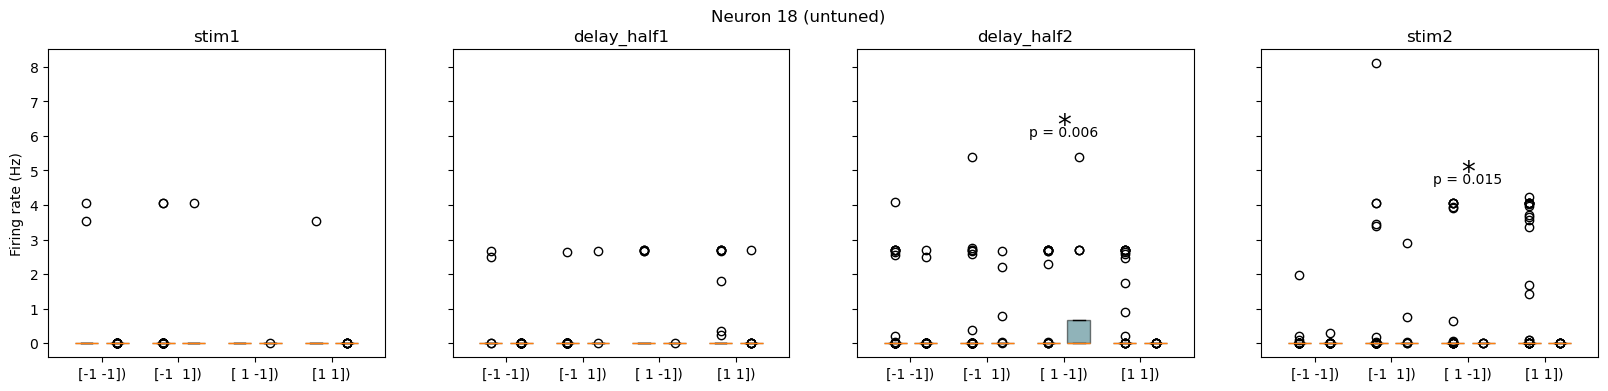

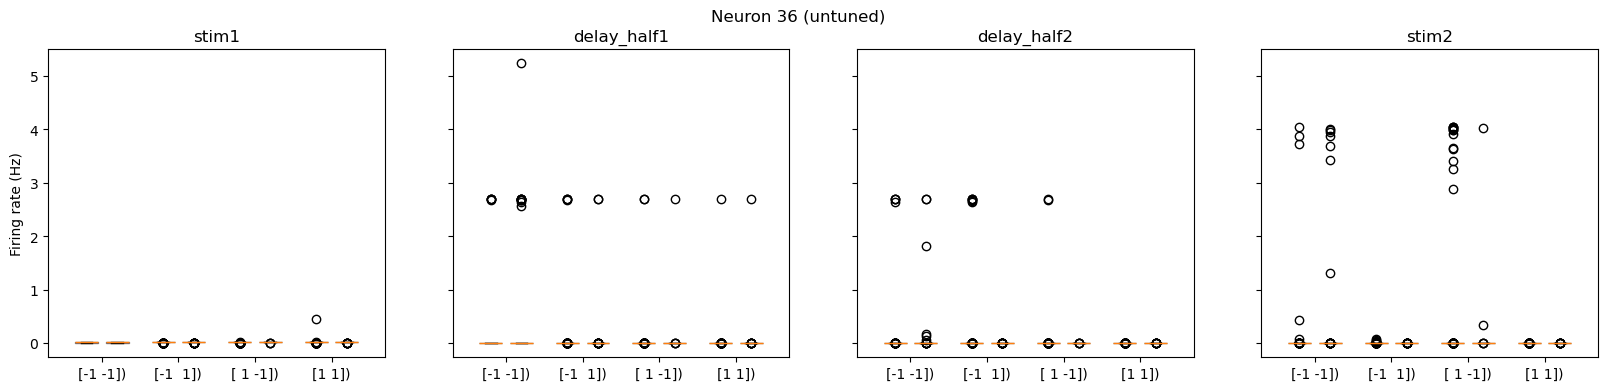

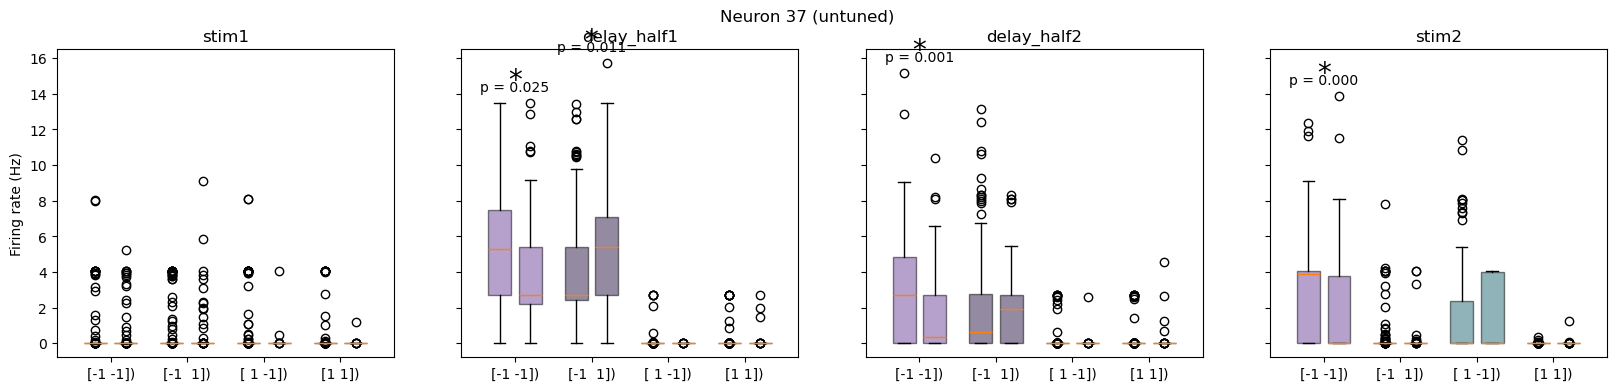

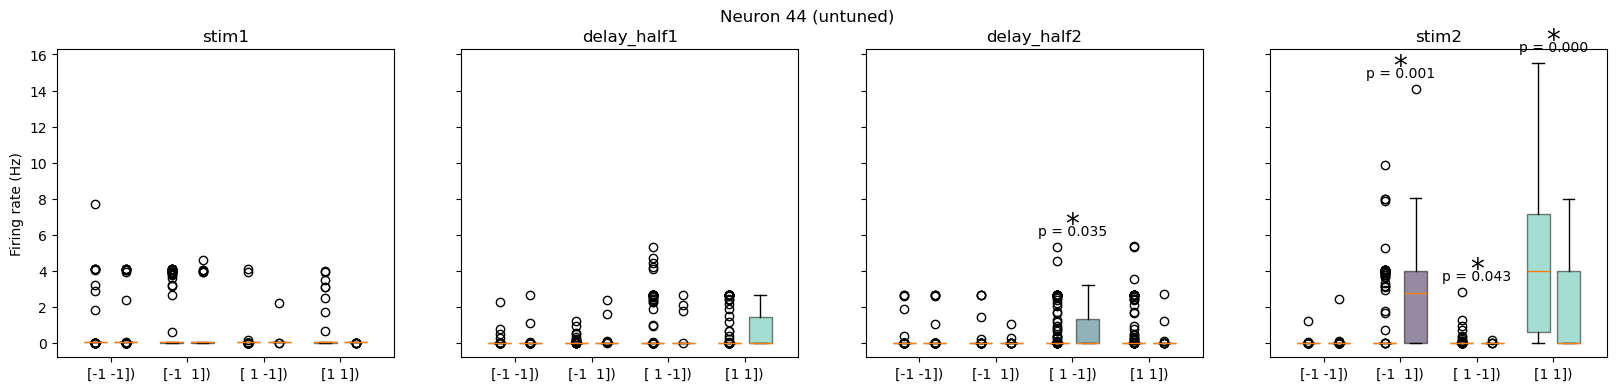

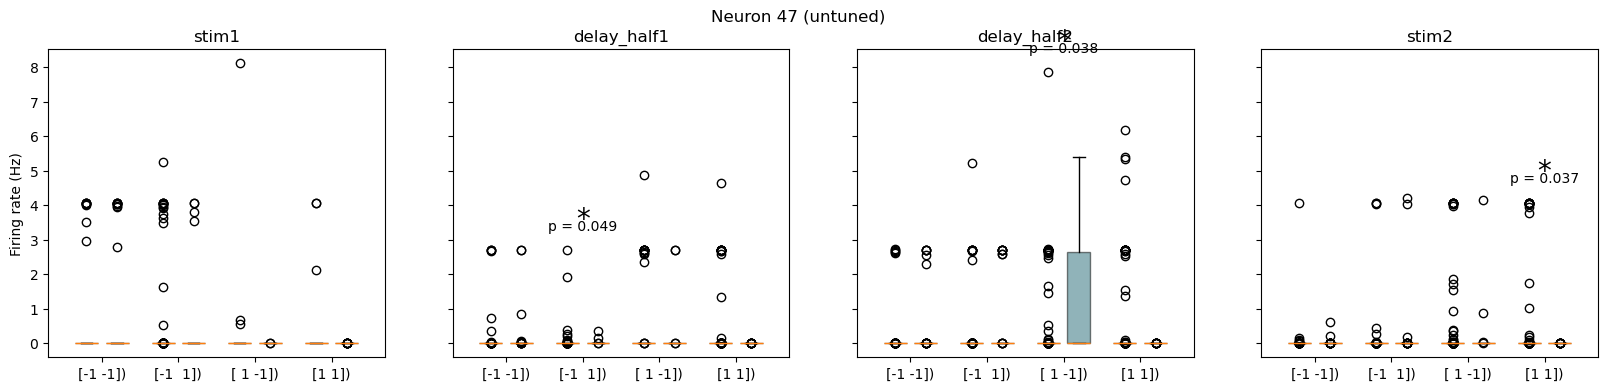

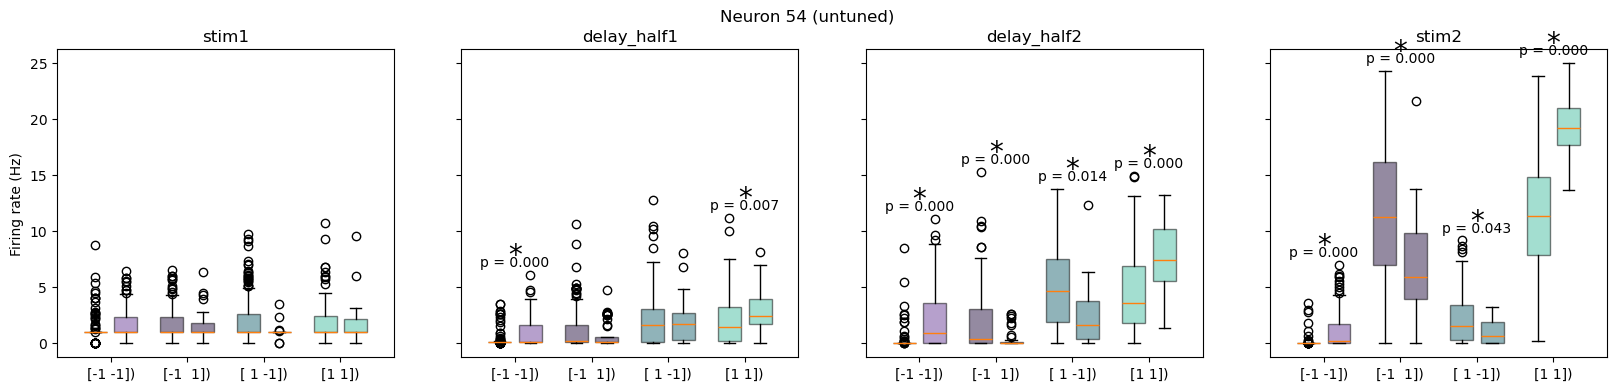

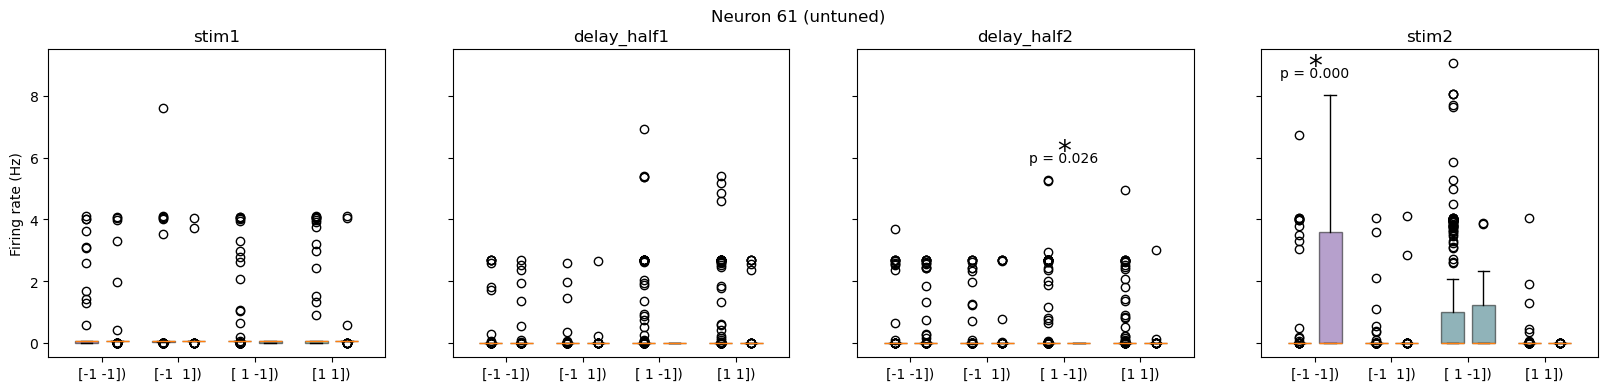

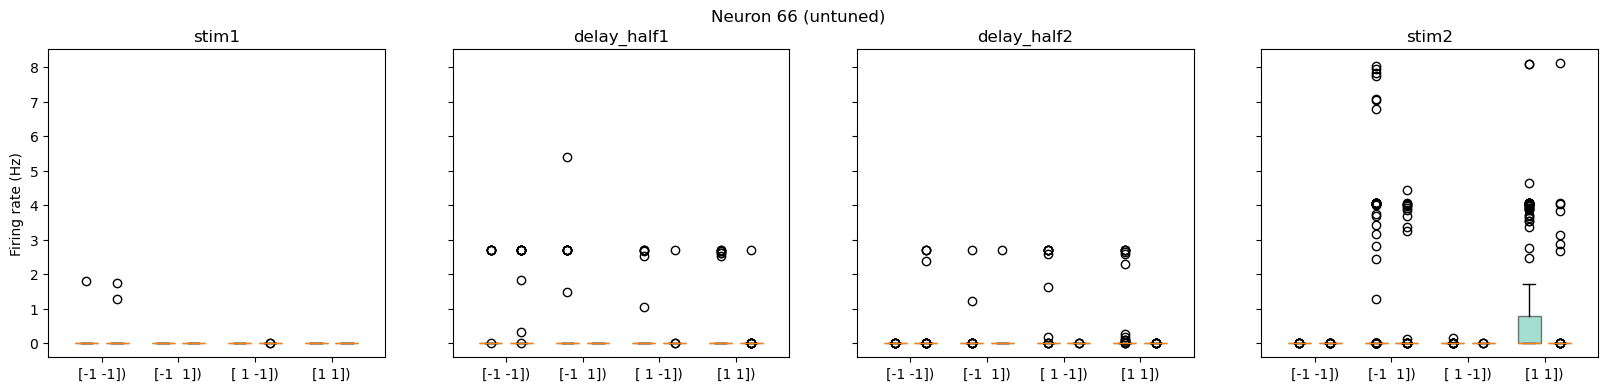

In [108]:
for neuron_idx in untuned_idxs[:10]:
    plot_violin_neuron_rates_timeavg_by_acc(model_name, neuron_idx, condn_phrase, condn_num, 
                                            rates_data = rates_data, periods = periods, plot=True,
                                            title=f'Neuron {neuron_idx} (untuned)')

In [ ]:
period_means = plot_violin_neuron_rates_timeavg_by_acc(model_name, untuned_idxs[0], condn_phrase, condn_num, 
                                            rates_data = rates_data, periods = None, plot = False,
                                            ax=None, title=None)

In [68]:
period_means

,period,trial_type,correct_rates,incorrect_rates
0,stim1,"[-1, -1]","[0.8993615369796752, 0.8993615369796752, 0.0, ...","[0.0, 0.8993615369796752, 0.8993615369796752, ..."
1,stim1,"[-1, 1]","[0.8993615369796752, 0.8993615369796752, 0.899...","[0.0, 0.0, 0.0, 0.8993615369796752, 0.89936153..."
2,stim1,"[1, -1]","[0.8993615369796752, 0.8993615369796752, 4.245...","[0.0, 0.8993615369796752, 0.8993615369796752, ..."
3,stim1,"[1, 1]","[0.8993615369796752, 0.8993615369796752, 0.0, ...","[7.73053010559082, 0.0, 0.8993615369796752, 0...."
4,delay_half1,"[-1, -1]","[4.500221000254154, 2.824606400912007, 1.44721...","[3.0809591573079427, 2.411762837936481, 0.0652..."
5,delay_half1,"[-1, 1]","[0.9916350581397613, 8.419761522372564, 0.0652...","[1.5755229919751486, 8.931266225894293, 1.9196..."
6,delay_half1,"[1, -1]","[0.06522904223452011, 0.06522904223452011, 0.5...","[0.0, 0.06522904223452011, 0.06522904223452011..."
7,delay_half1,"[1, 1]","[0.06522904223452011, 0.06522904223452011, 0.0...","[0.8829512355526289, 0.0, 0.06522904223452011,..."
8,delay_half2,"[-1, -1]","[5.8596708202362064, 2.5572491405804954, 4.795...","[2.244402000904083, 0.34403597524762153, 0.002..."
9,delay_half2,"[-1, 1]","[3.158731829325358, 2.3681731526056926, 2.6110...","[2.915604536851247, 8.137892824808757, 0.75410..."


### look at the postsynaptic connections..

Average number of postsyn neurons per untuned neuron: 1.3529411764705883


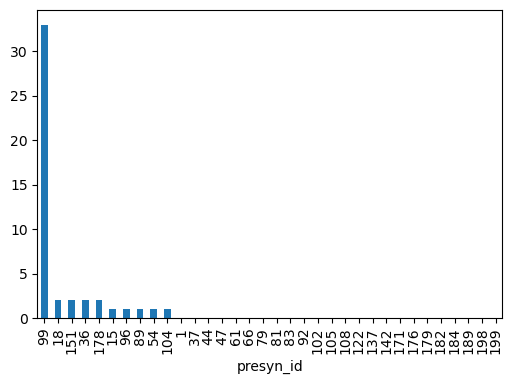

In [49]:
# peek at the post-synaptic connections..

untuned_postsyn_connect = connectivity_df[connectivity_df['presyn_id'].isin(untuned_idxs)]
# sort the connectivity by the postsynaptic neuron
untuned_postsyn_connect = untuned_postsyn_connect.sort_values(by='presyn_id')


# average number of presyn neurons per untuned neuron
counts = untuned_postsyn_connect['presyn_id'].value_counts()
for neuron_idx in untuned_idxs:
    if neuron_idx not in counts.index:
        counts[neuron_idx] = 0
avg_num_postsyn = np.mean(counts)
print(f'Average number of postsyn neurons per untuned neuron: {avg_num_postsyn}')

# plot the number of connections per untuned neuron
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
counts.plot(kind='bar', ax=ax);

In [ ]:
# average number presyn connections per neuron
avg_presyn = np.mean(connectivity_df['postsyn_id'].value_counts())
print(f'Average number of presynaptic connections per neuron: {avg_presyn}')

# average number presyn connections per exc neuron
exc_connectivity = connectivity_df[connectivity_df['postsyn_id'].isin(exc_ind)]
exc_connectivity = exc_connectivity.sort_values(by='postsyn_id')
# plot the number of connections per exc neuron
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
exc_connectivity['postsyn_id'].value_counts().plot(kind='bar', ax=ax)
# average number presyn connections per unique neuron
avg_presyn = np.mean(exc_connectivity['postsyn_id'].value_counts())
print(f'Average number of presynaptic connections per exc neuron: {avg_presyn}')

Average number of postsynaptic connections per neuron: 8.03
Average number of postsynaptic connections per exc neuron: 0.4140127388535032


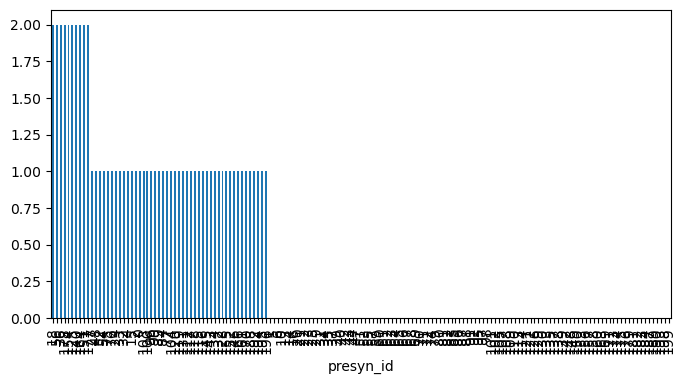

In [46]:
# average number postsyn connections per neuron
postsyn_counts = connectivity_df['presyn_id'].value_counts()
avg_postsyn = np.mean(postsyn_counts)*len(postsyn_counts) / 200 # mean to include all neurons incl ones with 0 postsynaptic connections 
print(f'Average number of postsynaptic connections per neuron: {avg_postsyn}')

# average number presyn connections per exc neuron
exc_connectivity = connectivity_df[connectivity_df['presyn_id'].isin(exc_ind)]
exc_connectivity = exc_connectivity.sort_values(by='presyn_id')
# average number presyn connections per unique neuron
exc_postsyn_counts = exc_connectivity['presyn_id'].value_counts()
for neuron_idx in exc_ind:
    if neuron_idx not in exc_postsyn_counts.index:
        exc_postsyn_counts[neuron_idx] = 0
avg_exc_postsyn = np.mean(exc_postsyn_counts) # mean to include all exc neurons incl ones with 0 postsynaptic connections
print(f'Average number of postsynaptic connections per exc neuron: {avg_exc_postsyn}')

# plot the number of connections per exc neuron
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
exc_postsyn_counts.plot(kind='bar', ax=ax);

In [50]:
def get_num_postsyn(connectivity_df, neuron_idxs):
    # get the connectivity of the neurons of interest
    connectivity = connectivity_df[connectivity_df['presyn_id'].isin(neuron_idxs)]
    # sort the connectivity by the postsynaptic neuron
    connectivity = connectivity.sort_values(by='presyn_id')
    # get the number of presynaptic connections per neuron
    num_postsyn = connectivity['presyn_id'].value_counts()

    # if some neuron idxs weren't included, add them as rows of zeros
    for neuron_idx in neuron_idxs:
        if neuron_idx not in num_postsyn.index:
            num_postsyn[neuron_idx] = 0
    # sort the index
    num_postsyn = num_postsyn.sort_index()

    return num_postsyn
# get the number of postsynaptic connections per neuron for each category
exc_num_postsyn = get_num_postsyn(connectivity_df, exc_ind)
exc_ind_tuned = np.setdiff1d(exc_ind, untuned_idxs) # exclude the exc neurons that are also untuned
exc_tuned_num_postsyn = get_num_postsyn(connectivity_df, exc_ind_tuned) # exclude the exc neurons that are also untuned
inh_num_postsyn = get_num_postsyn(connectivity_df, inh_ind)
inh_ind_tuned = np.setdiff1d(inh_ind, untuned_idxs) # exclude the inh neurons that are also untuned
inh_tuned_num_postsyn = get_num_postsyn(connectivity_df, inh_ind_tuned) # exclude the inh neurons that are also untuned
# get the number of postsynaptic connections per neuron for the untuned neurons
untuned_num_postsyn = get_num_postsyn(connectivity_df, untuned_idxs)
# get the number of postsynaptic connections per neuron for all neurons
all_num_postsyn = get_num_postsyn(connectivity_df, np.arange(0, rates_data.shape[1]))

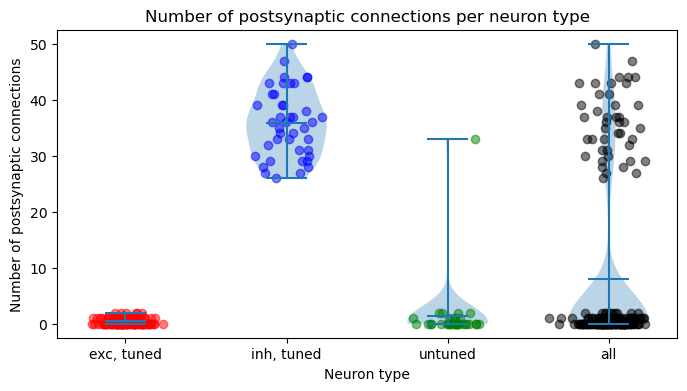

exc vs inh p = 0.00000
exc tuned vs inh tuned p = 0.00000
exc tuned vs untuned p = 0.71162


In [54]:
# plot as violinplot

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.violinplot([exc_tuned_num_postsyn, inh_tuned_num_postsyn, untuned_num_postsyn, all_num_postsyn], showmeans=True)
# plot scatter points
ax.scatter(np.random.normal(1, 0.1, size=len(exc_tuned_num_postsyn)), exc_tuned_num_postsyn, color='r', alpha=0.5)
ax.scatter(np.random.normal(2, 0.1, size=len(inh_tuned_num_postsyn)), inh_tuned_num_postsyn, color='b', alpha=0.5)
ax.scatter(np.random.normal(3, 0.1, size=len(untuned_num_postsyn)), untuned_num_postsyn, color='g', alpha=0.5)
ax.scatter(np.random.normal(4, 0.1, size=len(all_num_postsyn)), all_num_postsyn, color='k', alpha=0.5)
ax.set_ylabel('Number of postsynaptic connections')
ax.set_xlabel('Neuron type')
ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels(['exc, tuned', 'inh, tuned', 'untuned', 'all'])
ax.set_title('Number of postsynaptic connections per neuron type')
plt.show()


# stats on this
exc_inh_p = scipy.stats.mannwhitneyu(exc_num_postsyn, inh_num_postsyn, alternative='two-sided')[1]
exc_inh_tuned_p = scipy.stats.mannwhitneyu(exc_tuned_num_postsyn, inh_tuned_num_postsyn, alternative='two-sided')[1]
exc_untuned_p = scipy.stats.mannwhitneyu(exc_tuned_num_postsyn, untuned_num_postsyn, alternative='two-sided')[1]

print(f'exc vs inh p = {exc_inh_p:.5f}')
print(f'exc tuned vs inh tuned p = {exc_inh_tuned_p:.5f}')
print(f'exc tuned vs untuned p = {exc_untuned_p:.5f}')
